In [1]:
#undef __noinline__

# Simple ray tracer

In [2]:
#include <stdlib.h>
#include <stdio.h>
#include <math.h>

#define INF 2e10f
#define rnd( x ) (x * (float)rand() / RAND_MAX)
#define SPHERES 20
#define DIM 1024

In [3]:
struct Sphere {
    float r, b, g;
    float radius;
    float x, y, z;

    __device__ float hit(float ox, float oy, float *n) {
        float dx = ox - x;
        float dy = oy - y;
        float radius2 = radius * radius;
        float distance2 = dx * dx + dy * dy;

        if (distance2 < radius2) {
            float diff = radius2 - distance2;
            float dz;

            // --- Inline PTX Assembly Start ---
            // %0 is dz (output), %1 is diff (input)
            // sqrt.rn.f32 = Square Root, Round to Nearest, Float 32-bit
            asm("sqrt.rn.f32 %0, %1;" : "=f"(dz) : "f"(diff));
            // --- Inline PTX Assembly End ---

            *n = dz / radius;
            return dz + z;
        }
        return -INF;
    }
};

In [4]:
__global__ void kernel( Sphere *s, unsigned char *ptr ) {
    int x = threadIdx.x + blockIdx.x * blockDim.x;
    int y = threadIdx.y + blockIdx.y * blockDim.y;
    int offset = x + y * blockDim.x * gridDim.x;

    float ox = (x - DIM/2.0f);
    float oy = (y - DIM/2.0f);

    float r=0, g=0, b=0;
    float maxz = -INF;

    for(int i=0; i<SPHERES; i++) {
        float n;
        float t = s[i].hit( ox, oy, &n );
        if (t > maxz) {
            float fscale = n;
            r = s[i].r * fscale;
            g = s[i].g * fscale;
            b = s[i].b * fscale;
            maxz = t; // This ensures the front-most sphere is drawn
        }
    }

    ptr[offset*4 + 0] = (int)(r * 255);
    ptr[offset*4 + 1] = (int)(g * 255);
    ptr[offset*4 + 2] = (int)(b * 255);
    ptr[offset*4 + 3] = 255;
}

In [5]:
unsigned char *dev_bitmap;
Sphere *s_dev;
unsigned char *host_bitmap = (unsigned char*)malloc( DIM * DIM * 4 );

cudaMalloc( (void**)&dev_bitmap, DIM * DIM * 4 );
cudaMalloc( (void**)&s_dev, sizeof(Sphere) * SPHERES );

Sphere *temp_s = (Sphere*)malloc( sizeof(Sphere) * SPHERES );
for (int i=0; i<SPHERES; i++) {
    temp_s[i].r = rnd( 1.0f );
    temp_s[i].g = rnd( 1.0f );
    temp_s[i].b = rnd( 1.0f );
    temp_s[i].x = rnd( 1000.0f ) - 500;
    temp_s[i].y = rnd( 1000.0f ) - 500;
    temp_s[i].z = rnd( 1000.0f ) - 500;
    temp_s[i].radius = rnd( 100.0f ) + 20;
}

In [6]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

cudaMemcpy( s_dev, temp_s, sizeof(Sphere) * SPHERES, cudaMemcpyHostToDevice );
free( temp_s );

dim3 grids(DIM/16, DIM/16);
dim3 threads(16,16);
kernel<<<grids,threads>>>( s_dev, dev_bitmap );

// Wait for GPU to finish before copying
cudaDeviceSynchronize();

cudaMemcpy( host_bitmap, dev_bitmap, DIM * DIM * 4, cudaMemcpyDeviceToHost );

// Save using the HOST pointer
stbi_write_png("assets/RayTrace.png", DIM, DIM, 4, host_bitmap, DIM*4);

// Cleanup
cudaFree( s_dev );
cudaFree( dev_bitmap );
free( host_bitmap );

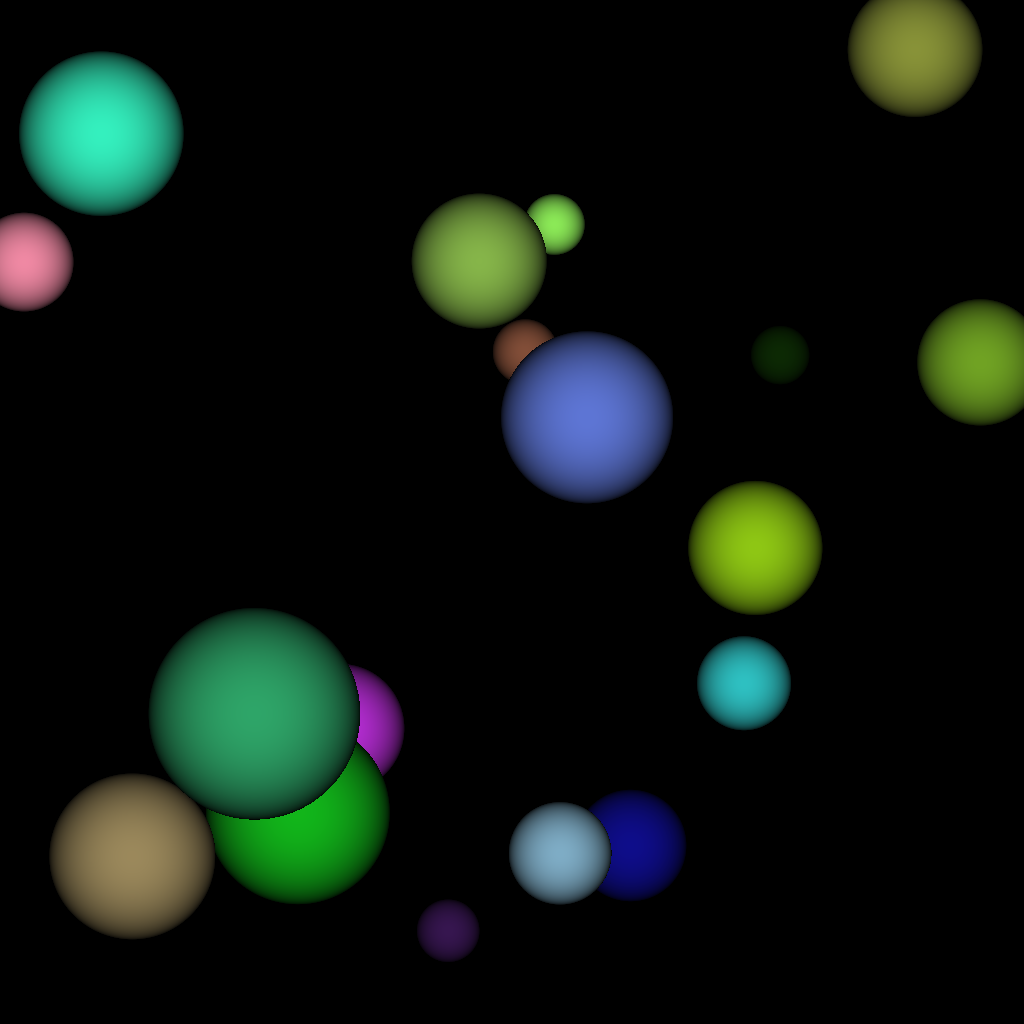

In [7]:
#include "headers/display.hpp"

im::image RT_image("assets/RayTrace.png");
xcpp::display(RT_image);